# 🏙️ Monitoreo de Expansión Urbana y Deforestación Agrícola en Galápagos
### Impacto del Crecimiento Demográfico en Santa Cruz — Puerto Ayora (2020 vs 2023)

**Problema:** El crecimiento poblacional en Galápagos genera dos presiones territoriales medibles desde satélite:  
1. **Expansión urbana** — Puerto Ayora crece hacia zonas de amortiguamiento  
2. **Deforestación agrícola** — ampliación de terrenos de cultivo en la zona húmeda  

**Sensores:** Sentinel-2 SR (10m) + GHSL — Global Human Settlement Layer  
**Índices:** NDVI · NDBI · BSI  
**Área:** Santa Cruz — zona urbana (Puerto Ayora) + tierras agrícolas intermedias  
**Período:** 2020 (base) vs 2023 (reciente)

---
## 1. 🛰️ Adquisición — Conexión a GEE e ImageCollection

In [40]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
from PIL import Image
from io import BytesIO

# Inicializar GEE
# ee.Authenticate()  # Solo la primera vez
ee.Initialize(project='galapagossafe')

print('✅ Conexión con Google Earth Engine exitosa')

✅ Conexión con Google Earth Engine exitosa


In [ ]:
# ── Áreas de estudio ──────────────────────────────────────────────────────────

# Isla Santa Cruz completa (zona agrícola + urbana)
santa_cruz = ee.Geometry.Rectangle([-90.45, -0.80, -90.15, -0.50])

# Zona urbana: Puerto Ayora + expansión periurbana
puerto_ayora = ee.Geometry.Rectangle([-90.33, -0.76, -90.20, -0.68])

# Zona agrícola: tierras intermedias entre lo urbano y el parque nacional
zona_agricola = ee.Geometry.Rectangle([-90.42, -0.72, -90.22, -0.58])

# ── Cargar Sentinel-2 SR ──────────────────────────────────────────────────────
def get_collection(start, end, aoi):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
        .sort('system:time_start')
    )

col_2020 = get_collection('2020-07-01', '2020-10-31', santa_cruz)
col_2023 = get_collection('2023-07-01', '2023-10-31', santa_cruz)

# ── Cargar GHSL: Global Human Settlement Layer ────────────────────────────────
# Dataset de asentamientos humanos de la UE — capas 2015 y 2020 disponibles
ghsl_2015 = ee.Image('JRC/GHSL/P2023A/GHS_BUILT_S/2010').clip(santa_cruz)
ghsl_2020 = ee.Image('JRC/GHSL/P2023A/GHS_BUILT_S/2020').clip(santa_cruz)

print(f'📦 Imágenes Sentinel-2 2020: {col_2020.size().getInfo()}')
print(f'📦 Imágenes Sentinel-2 2023: {col_2023.size().getInfo()}')
print('📦 GHSL 2015 y 2020 cargados')

📦 Imágenes Sentinel-2 2020: 28
📦 Imágenes Sentinel-2 2023: 27
📦 GHSL 2015 y 2020 cargados


---
## 2. ⚙️ Pre-procesamiento — Clipping, Nubes y Escala

In [42]:
# ── Máscara de nubes con SCL ──────────────────────────────────────────────────
def mask_clouds(image):
    scl = image.select('SCL')
    mask = (scl.neq(3).And(scl.neq(8))
               .And(scl.neq(9)).And(scl.neq(10)))
    return image.updateMask(mask)

# ── Escalar reflectancias a [0-1] ─────────────────────────────────────────────
def scale_bands(image):
    optical = image.select(['B2','B3','B4','B8','B11','B12'])
    return (image
            .addBands(optical.divide(10000), overwrite=True)
            .copyProperties(image, ['system:time_start']))

# ── Pipeline completo ─────────────────────────────────────────────────────────
def preprocess(collection, aoi):
    return (collection
            .map(mask_clouds)
            .map(scale_bands)
            .map(lambda img: img.clip(aoi)))

proc_2020 = preprocess(col_2020, santa_cruz)
proc_2023 = preprocess(col_2023, santa_cruz)

# Composites medianos
comp_2020 = proc_2020.median()
comp_2023 = proc_2023.median()

print('✅ Pre-procesamiento completo: clipping + nubes + reflectancias escaladas')
print('✅ Composites medianos 2020 y 2023 generados')

✅ Pre-procesamiento completo: clipping + nubes + reflectancias escaladas
✅ Composites medianos 2020 y 2023 generados


---
## 3. 🖼️ Visualización — 10 Imágenes (Fechas y Bandas)

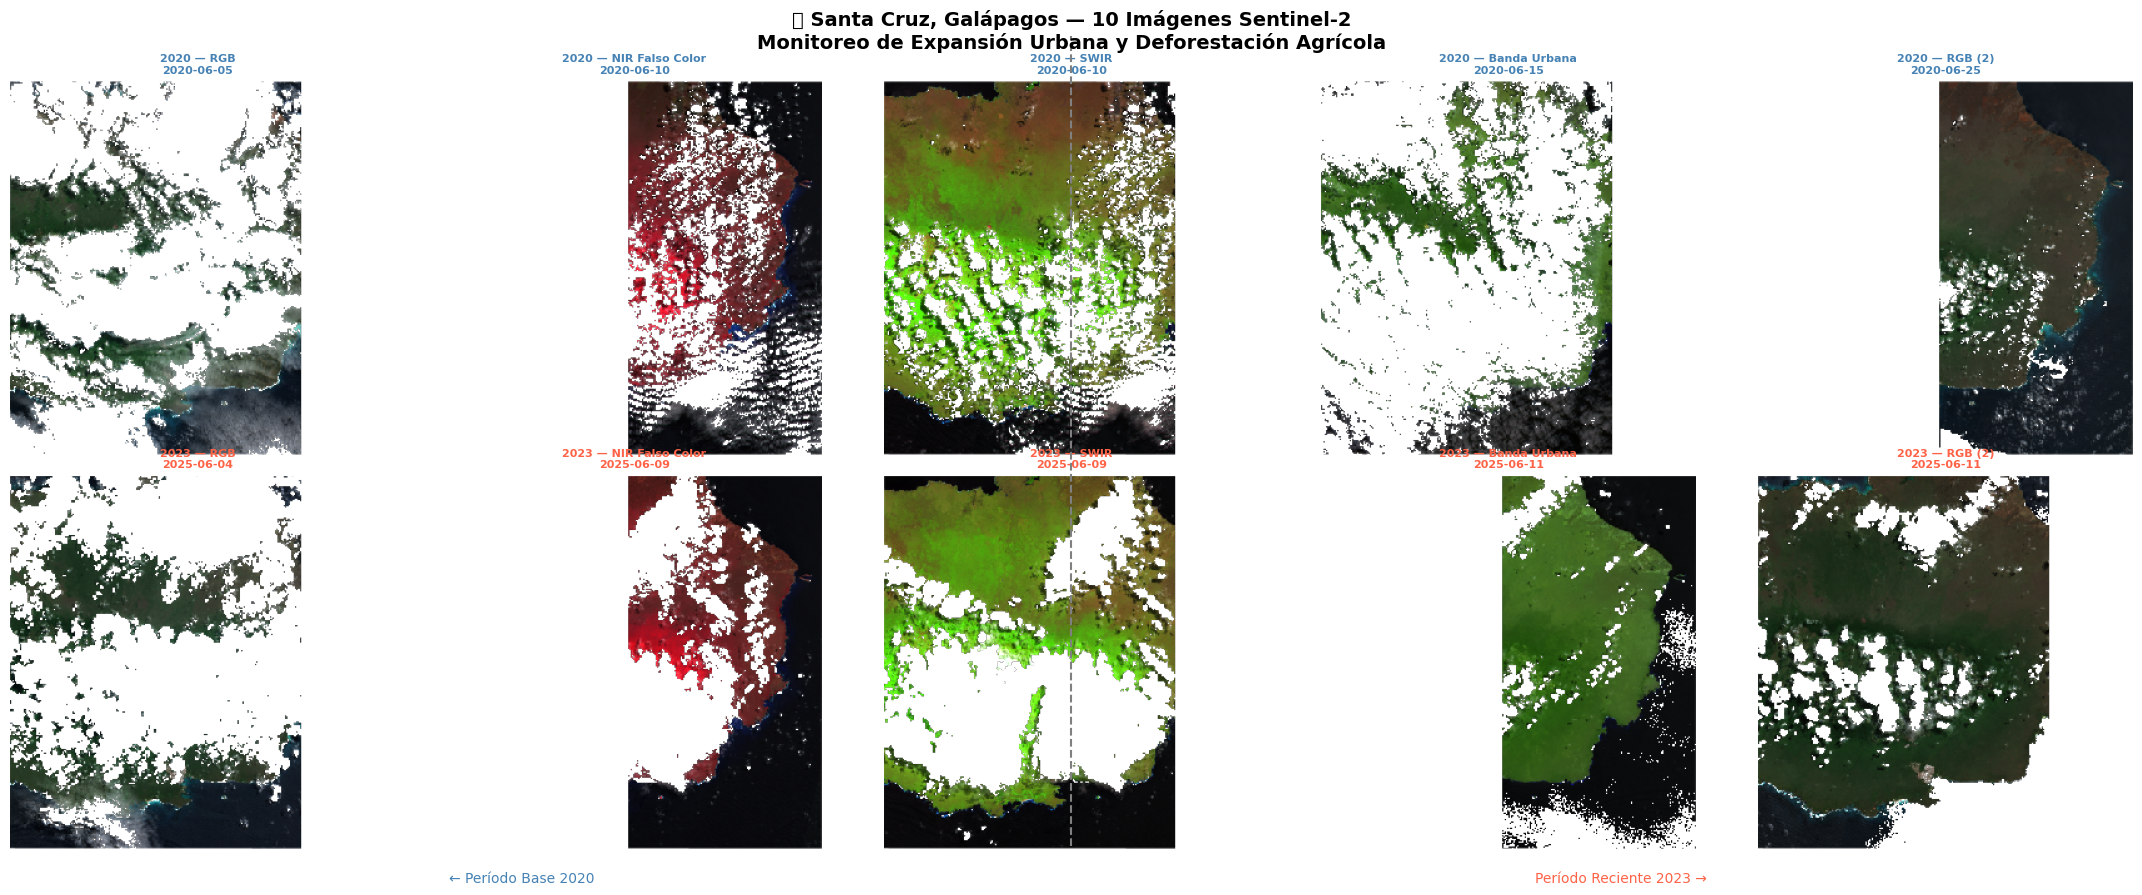

✅ 10 imágenes visualizadas (5×2020, 5×2023)


In [43]:
# ── Función auxiliar thumbnails ───────────────────────────────────────────────
def get_thumb(image, vis_params, region=santa_cruz, dim=300):
    url = image.getThumbURL({**vis_params, 'region': region,
                             'dimensions': dim, 'format': 'png'})
    resp = requests.get(url)
    return Image.open(BytesIO(resp.content))

# Parámetros de visualización
vis_rgb  = {'min': 0.0, 'max': 0.3,  'bands': ['B4','B3','B2']}
vis_nir  = {'min': 0.0, 'max': 0.5,  'bands': ['B8','B4','B3']}   # Falso color — vegetación en rojo
vis_swir = {'min': 0.0, 'max': 0.5,  'bands': ['B11','B8','B4']}  # SWIR — suelo/urbano en magenta
vis_urban = {'min': 0.0, 'max': 0.5, 'bands': ['B12','B11','B4']} # Resalta zonas construidas

# 5 imágenes de 2020 + 5 de 2023
imgs_2020 = proc_2020.toList(5)
imgs_2023 = proc_2023.toList(5)

configs = [
    (imgs_2020, 0, vis_rgb,   '2020 — RGB'),
    (imgs_2020, 1, vis_nir,   '2020 — NIR Falso Color'),
    (imgs_2020, 2, vis_swir,  '2020 — SWIR'),
    (imgs_2020, 3, vis_urban, '2020 — Banda Urbana'),
    (imgs_2020, 4, vis_rgb,   '2020 — RGB (2)'),
    (imgs_2023, 0, vis_rgb,   '2023 — RGB'),
    (imgs_2023, 1, vis_nir,   '2023 — NIR Falso Color'),
    (imgs_2023, 2, vis_swir,  '2023 — SWIR'),
    (imgs_2023, 3, vis_urban, '2023 — Banda Urbana'),
    (imgs_2023, 4, vis_rgb,   '2023 — RGB (2)'),
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('🏙️ Santa Cruz, Galápagos — 10 Imágenes Sentinel-2\n'
             'Monitoreo de Expansión Urbana y Deforestación Agrícola',
             fontsize=14, fontweight='bold')

for idx, (col_list, img_idx, vis, titulo) in enumerate(configs):
    ax = axes[idx // 5][idx % 5]
    img = ee.Image(col_list.get(img_idx))
    date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    thumb = get_thumb(img, vis)
    ax.imshow(thumb)
    color = 'steelblue' if idx < 5 else 'tomato'
    ax.set_title(f'{titulo}\n{date}', fontsize=8, fontweight='bold', color=color)
    ax.axis('off')

fig.add_artist(plt.Line2D([0.5, 0.5], [0.05, 0.95],
               transform=fig.transFigure, color='gray', lw=1.5, linestyle='--'))
fig.text(0.25, 0.01, '← Período Base 2020', ha='center', fontsize=10, color='steelblue')
fig.text(0.75, 0.01, 'Período Reciente 2023 →', ha='center', fontsize=10, color='tomato')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('galapagos_10_imagenes_urbano.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 10 imágenes visualizadas (5×2020, 5×2023)')

---
## 4. 🧮 Lógica Inicial — Índices Espectrales y Clasificación de Cobertura

### Estrategia espectral para detectar cambio urbano y agrícola

| Índice | Fórmula (Sentinel-2) | Detecta |
|--------|----------------------|---------|
| **NDVI** | `(B8 - B4) / (B8 + B4)` | Vegetación — pérdida indica deforestación |
| **NDBI** | `(B11 - B8) / (B11 + B8)` | Zonas construidas — positivo en urbano |
| **BSI** | `((B11+B4) - (B8+B2)) / ((B11+B4) + (B8+B2))` | Suelo desnudo — positivo en agricultura nueva |

**Nota metodológica:** Estos índices detectan *tipos de cobertura del suelo*, no actividad humana directamente.
El crecimiento urbano se infiere por aumento de NDBI y pérdida de NDVI en zonas periurbanas.
La deforestación agrícola se infiere por aumento de BSI en zonas que antes eran vegetación.

In [44]:
# ── Calcular índices ──────────────────────────────────────────────────────────
def calcular_indices(img):
    # NDVI — vegetación
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # NDBI — zonas construidas (valores positivos = urbano/artificial)
    ndbi = img.normalizedDifference(['B11', 'B8']).rename('NDBI')

    # BSI — suelo desnudo / agrícola
    bsi = img.expression(
        '((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))',
        {'B11': img.select('B11'), 'B4': img.select('B4'),
         'B8':  img.select('B8'),  'B2': img.select('B2')}
    ).rename('BSI')

    return ndvi, ndbi, bsi

ndvi_2020, ndbi_2020, bsi_2020 = calcular_indices(comp_2020)
ndvi_2023, ndbi_2023, bsi_2023 = calcular_indices(comp_2023)

print('✅ Índices calculados: NDVI, NDBI, BSI — para 2020 y 2023')

✅ Índices calculados: NDVI, NDBI, BSI — para 2020 y 2023


In [45]:
# ── Clasificación de cobertura por umbrales ───────────────────────────────────
# Clases:
#   0 — Agua              (NDVI < -0.1)
#   1 — Urbano/construido (NDBI > 0.0)
#   2 — Suelo/Agricultura (BSI > 0.0, no urbano)
#   3 — Vegetación baja   (NDVI 0.1–0.4)
#   4 — Vegetación densa  (NDVI > 0.4)

def clasificar(ndvi, ndbi, bsi):
    agua       = ndvi.lt(-0.1)
    urbano     = ndbi.gt(0.0).And(agua.Not())
    suelo_agri = bsi.gt(0.0).And(urbano.Not()).And(agua.Not())
    veg_baja   = ndvi.gte(0.1).And(ndvi.lt(0.4)).And(urbano.Not()).And(suelo_agri.Not())
    veg_densa  = ndvi.gte(0.4).And(urbano.Not()).And(suelo_agri.Not())

    clasificacion = (
        agua.multiply(0)
        .add(urbano.multiply(1))
        .add(suelo_agri.multiply(2))
        .add(veg_baja.multiply(3))
        .add(veg_densa.multiply(4))
    ).rename('cobertura')
    return clasificacion

clases_2020 = clasificar(ndvi_2020, ndbi_2020, bsi_2020)
clases_2023 = clasificar(ndvi_2023, ndbi_2023, bsi_2023)

# ── Mapas de cambio específicos ───────────────────────────────────────────────
# Expansión urbana: píxeles que pasaron a urbano (clase 1) desde cualquier otra clase
expansion_urbana = clases_2023.eq(1).And(clases_2020.neq(1)).rename('expansion_urbana')

# Deforestación agrícola: píxeles que pasaron de vegetación densa (4) a suelo/agri (2)
deforestacion = clases_2023.eq(2).And(clases_2020.eq(4)).rename('deforestacion')

print('✅ Clasificación de 5 clases aplicada para 2020 y 2023')
print('✅ Mapa de expansión urbana calculado')
print('✅ Mapa de deforestación agrícola calculado')

✅ Clasificación de 5 clases aplicada para 2020 y 2023
✅ Mapa de expansión urbana calculado
✅ Mapa de deforestación agrícola calculado


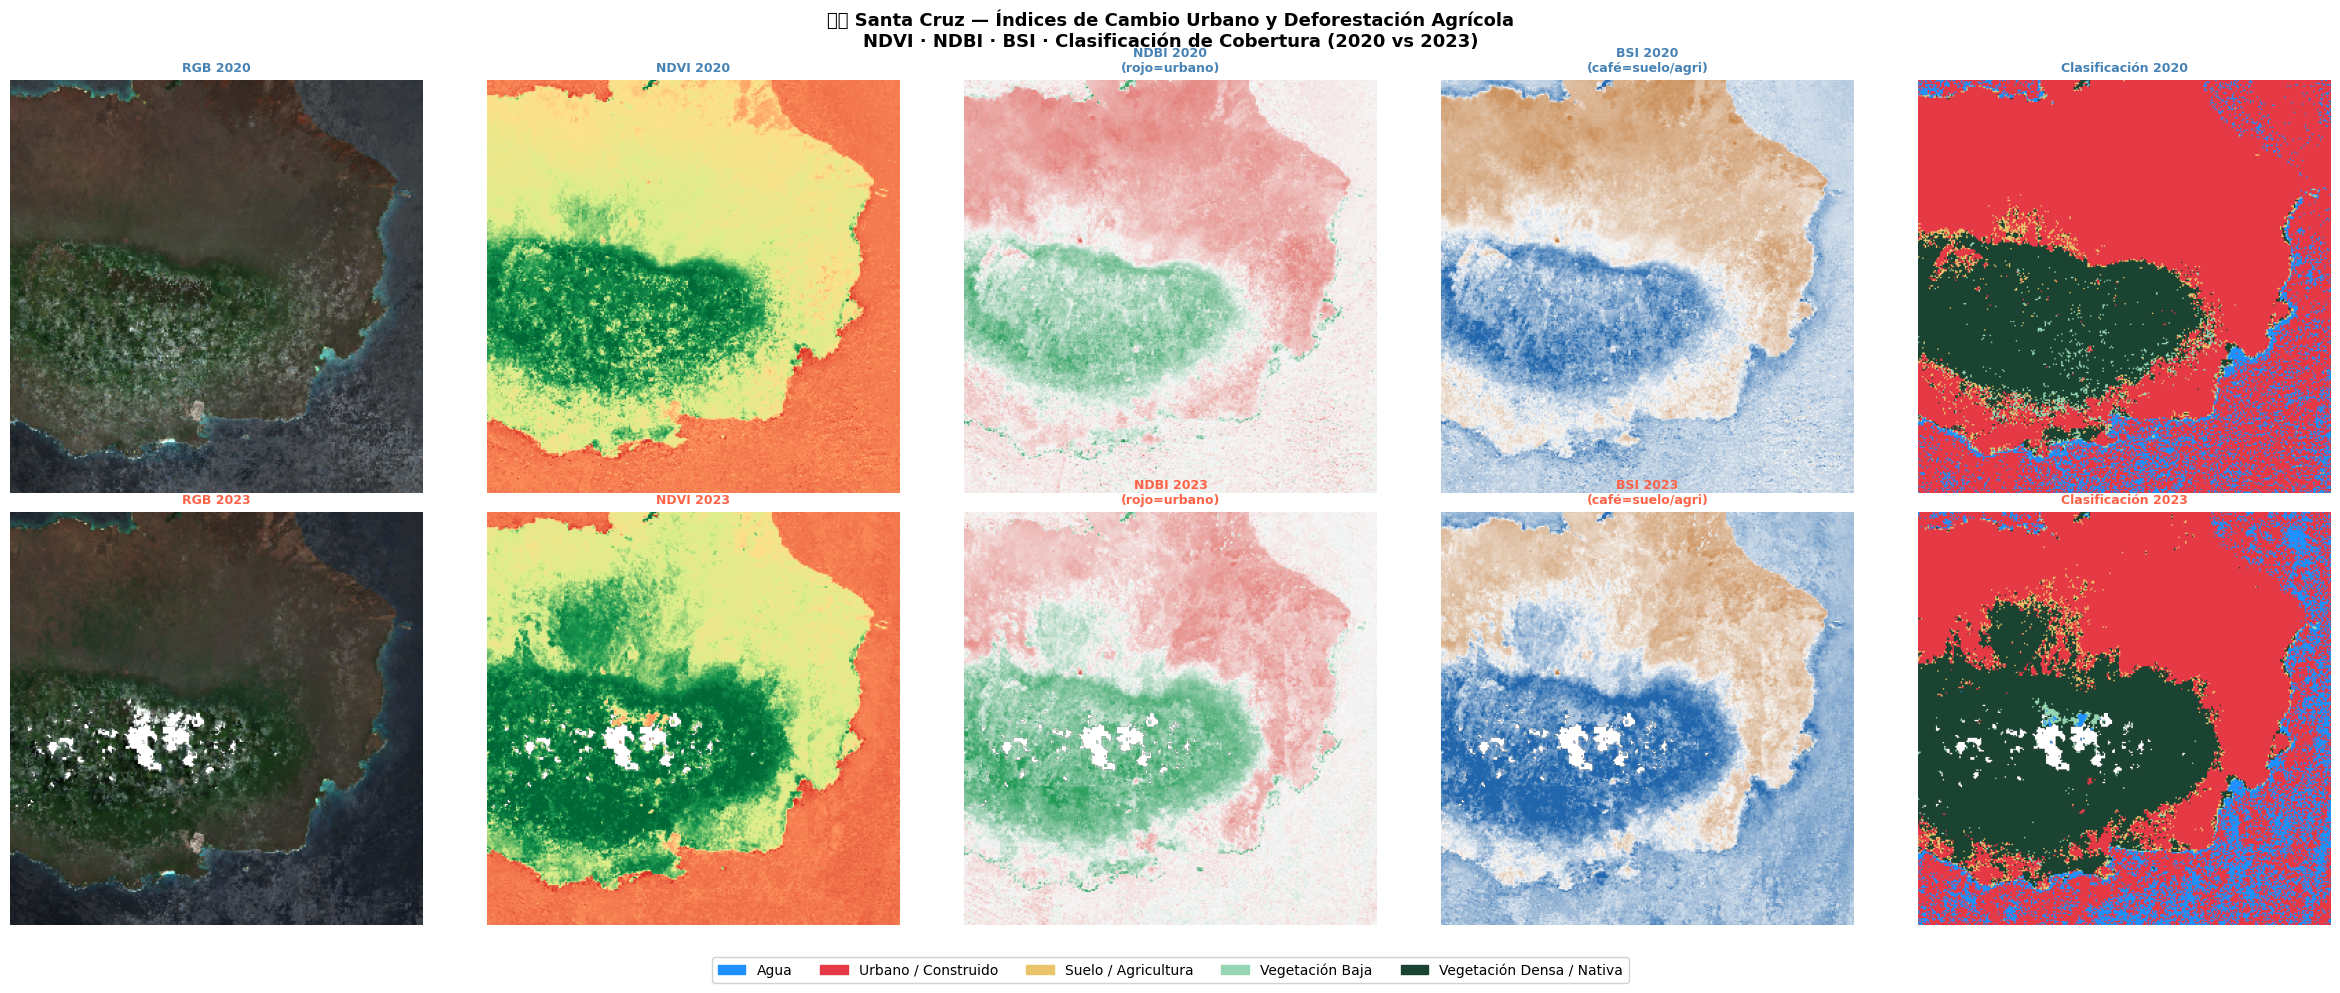

✅ Visualización de índices y clasificación completada


In [46]:
# ── Visualizar índices comparativos 2020 vs 2023 ──────────────────────────────
vis_ndvi = {'min': -0.2, 'max': 0.8,
            'palette': ['#d73027','#fc8d59','#fee08b','#d9ef8b','#1a9850','#006837']}
vis_ndbi = {'min': -0.5, 'max': 0.5,
            'palette': ['#1a9850','#f7f7f7','#d73027']}  # verde=natural, rojo=urbano
vis_bsi  = {'min': -0.3, 'max': 0.4,
            'palette': ['#2166ac','#f7f7f7','#b35806']}  # azul=veg, café=suelo
vis_clas = {'min': 0, 'max': 4,
            'palette': ['#1E90FF','#e63946','#e9c46a','#95d5b2','#1b4332']}
            # agua / urbano / suelo-agri / veg baja / veg densa

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('🏙️🌿 Santa Cruz — Índices de Cambio Urbano y Deforestación Agrícola\n'
             'NDVI · NDBI · BSI · Clasificación de Cobertura (2020 vs 2023)',
             fontsize=13, fontweight='bold')

celdas = [
    # Fila 1: 2020
    (comp_2020,   vis_rgb,  'RGB 2020'),
    (ndvi_2020,   vis_ndvi, 'NDVI 2020'),
    (ndbi_2020,   vis_ndbi, 'NDBI 2020\n(rojo=urbano)'),
    (bsi_2020,    vis_bsi,  'BSI 2020\n(café=suelo/agri)'),
    (clases_2020, vis_clas, 'Clasificación 2020'),
    # Fila 2: 2023
    (comp_2023,   vis_rgb,  'RGB 2023'),
    (ndvi_2023,   vis_ndvi, 'NDVI 2023'),
    (ndbi_2023,   vis_ndbi, 'NDBI 2023\n(rojo=urbano)'),
    (bsi_2023,    vis_bsi,  'BSI 2023\n(café=suelo/agri)'),
    (clases_2023, vis_clas, 'Clasificación 2023'),
]

for idx, (img_ee, vis, titulo) in enumerate(celdas):
    ax = axes[idx // 5][idx % 5]
    thumb = get_thumb(img_ee, vis)
    ax.imshow(thumb)
    color = 'steelblue' if idx < 5 else 'tomato'
    ax.set_title(titulo, fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

leyenda = [
    mpatches.Patch(color='#1E90FF', label='Agua'),
    mpatches.Patch(color='#e63946', label='Urbano / Construido'),
    mpatches.Patch(color='#e9c46a', label='Suelo / Agricultura'),
    mpatches.Patch(color='#95d5b2', label='Vegetación Baja'),
    mpatches.Patch(color='#1b4332', label='Vegetación Densa / Nativa'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=5,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('galapagos_indices_urbano_agricola.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización de índices y clasificación completada')

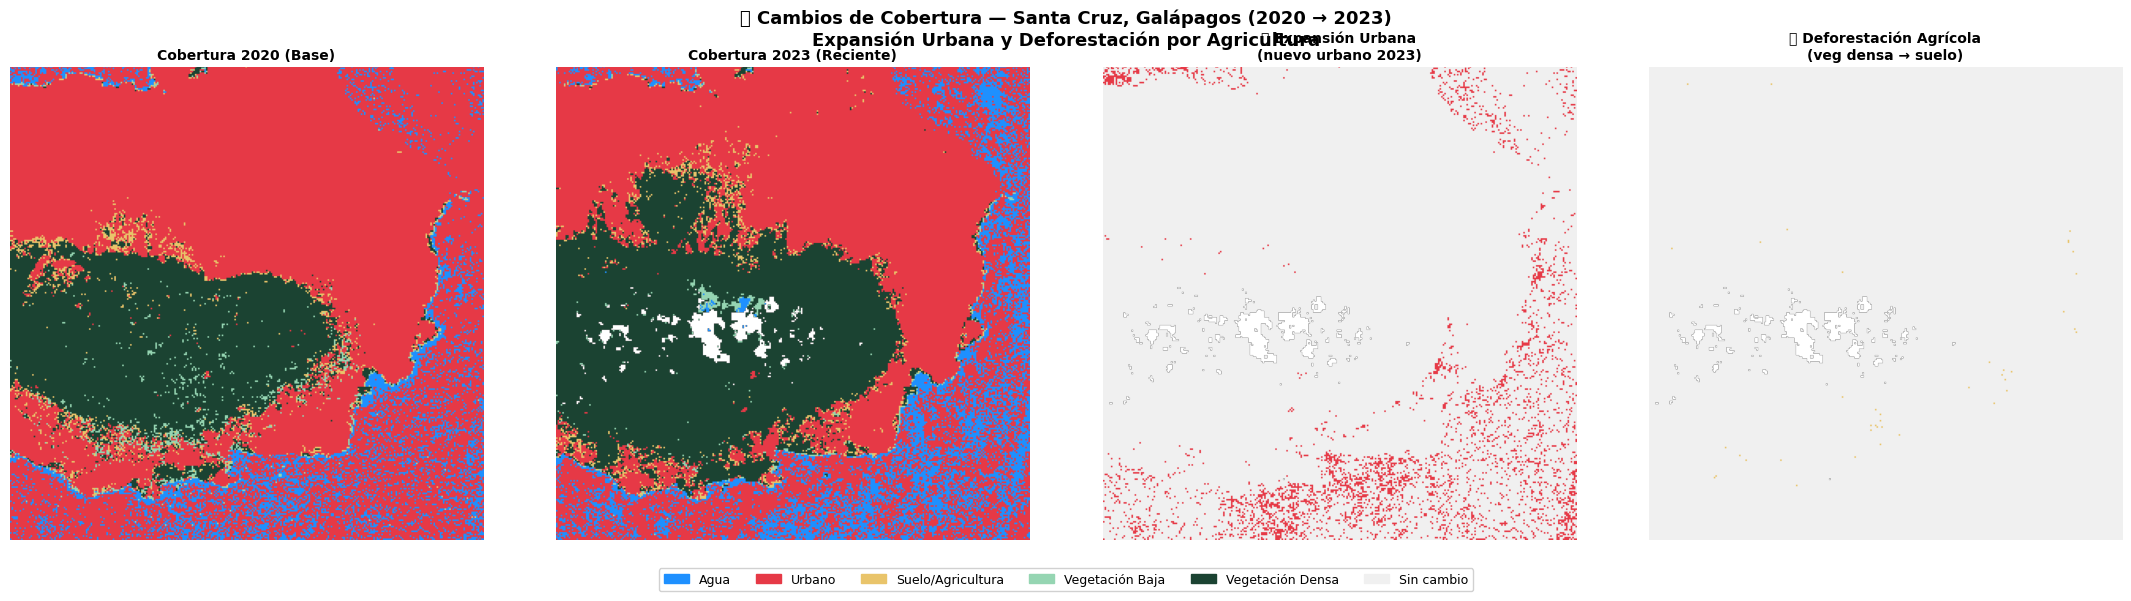

✅ Mapas de cambio generados


In [47]:
# ── Mapas de cambio: expansión urbana + deforestación ────────────────────────
vis_cambio_urbano = {'min': 0, 'max': 1, 'palette': ['#f0f0f0', '#e63946']}
vis_cambio_defor  = {'min': 0, 'max': 1, 'palette': ['#f0f0f0', '#e9c46a']}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('🚨 Cambios de Cobertura — Santa Cruz, Galápagos (2020 → 2023)\n'
             'Expansión Urbana y Deforestación por Agricultura',
             fontsize=13, fontweight='bold')

for ax, (img_ee, vis, titulo) in zip(axes, [
    (clases_2020,      vis_clas,          'Cobertura 2020 (Base)'),
    (clases_2023,      vis_clas,          'Cobertura 2023 (Reciente)'),
    (expansion_urbana, vis_cambio_urbano, '🔴 Expansión Urbana\n(nuevo urbano 2023)'),
    (deforestacion,    vis_cambio_defor,  '🟡 Deforestación Agrícola\n(veg densa → suelo)'),
]):
    thumb = get_thumb(img_ee, vis)
    ax.imshow(thumb)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.axis('off')

leyenda2 = [
    mpatches.Patch(color='#1E90FF', label='Agua'),
    mpatches.Patch(color='#e63946', label='Urbano'),
    mpatches.Patch(color='#e9c46a', label='Suelo/Agricultura'),
    mpatches.Patch(color='#95d5b2', label='Vegetación Baja'),
    mpatches.Patch(color='#1b4332', label='Vegetación Densa'),
    mpatches.Patch(color='#f0f0f0', label='Sin cambio'),
]
fig.legend(handles=leyenda2, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('galapagos_cambio_urbano_deforestacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mapas de cambio generados')

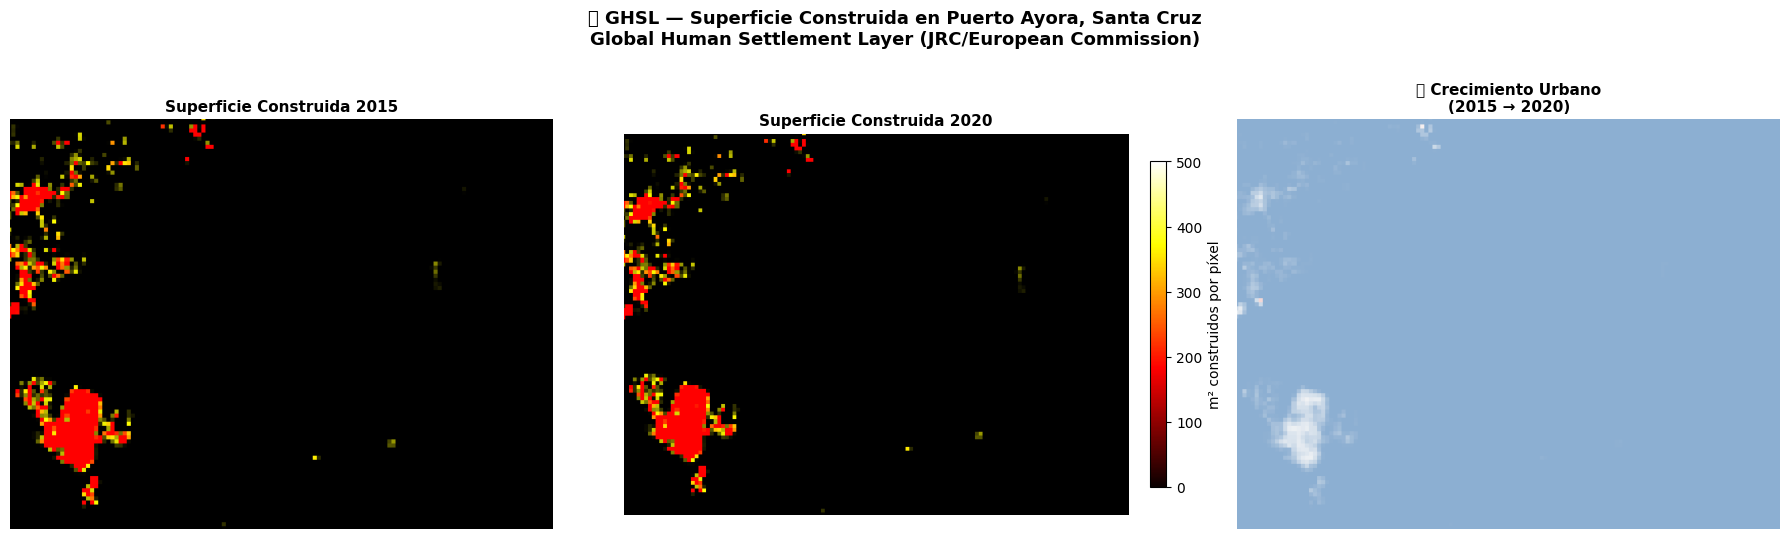

✅ Análisis GHSL completado — Puerto Ayora


In [48]:
# ── GHSL: Asentamientos humanos 2015 vs 2020 ──────────────────────────────────
# IMPORTANTE: GHSL tiene múltiples bandas → hay que seleccionar 'built_surface'
# antes de aplicar una paleta. Paleta solo funciona con imágenes de 1 banda.
ghsl_2015_b = ghsl_2015.select('built_surface')
ghsl_2020_b = ghsl_2020.select('built_surface')

# Cambio GHSL: diferencia de superficie construida entre años
ghsl_cambio = ghsl_2020_b.subtract(ghsl_2015_b).rename('cambio_ghsl')

vis_ghsl        = {'min': 0,    'max': 500, 'palette': ['#000000','#ffff00','#ff0000']}
vis_ghsl_cambio = {'min': -100, 'max': 300, 'palette': ['#2166ac','#f7f7f7','#d73027']}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🏘️ GHSL — Superficie Construida en Puerto Ayora, Santa Cruz\n'
             'Global Human Settlement Layer (JRC/European Commission)',
             fontsize=13, fontweight='bold')

for ax, (img_ee, vis, titulo) in zip(axes, [
    (ghsl_2015_b, vis_ghsl,        'Superficie Construida 2015'),
    (ghsl_2020_b, vis_ghsl,        'Superficie Construida 2020'),
    (ghsl_cambio, vis_ghsl_cambio, '🔴 Crecimiento Urbano\n(2015 → 2020)'),
]):
    thumb = get_thumb(img_ee, vis, region=puerto_ayora, dim=400)
    ax.imshow(thumb)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

# Barra de color referencial
sm = plt.cm.ScalarMappable(cmap='hot', norm=plt.Normalize(vmin=0, vmax=500))
plt.colorbar(sm, ax=axes[1], orientation='vertical',
             fraction=0.03, pad=0.04, label='m² construidos por píxel')

plt.tight_layout()
plt.savefig('galapagos_ghsl_urbano.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Análisis GHSL completado — Puerto Ayora')

In [49]:
# ── Estadísticas de cambio ────────────────────────────────────────────────────
def stat_indice(img, nombre, region, scale=500):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean().combine(
                 ee.Reducer.percentile([25, 75]), sharedInputs=True),
        geometry=region,
        scale=scale,
        maxPixels=1e9
    ).getInfo()
    mean = stats.get(f'{nombre}_mean', float('nan'))
    p25  = stats.get(f'{nombre}_p25',  float('nan'))
    p75  = stats.get(f'{nombre}_p75',  float('nan'))
    return mean, p25, p75

print('📊 Estadísticas — Santa Cruz completa:')
print()
for label, n20, n23, nombre in [
    ('NDVI', ndvi_2020, ndvi_2023, 'NDVI'),
    ('NDBI', ndbi_2020, ndbi_2023, 'NDBI'),
    ('BSI',  bsi_2020,  bsi_2023,  'BSI'),
]:
    m20, p25_20, p75_20 = stat_indice(n20, nombre, santa_cruz)
    m23, p25_23, p75_23 = stat_indice(n23, nombre, santa_cruz)
    delta = m23 - m20
    signo = '📈' if delta > 0 else '📉'
    print(f'  {label}:')
    print(f'    2020 → media={m20:.3f}  P25={p25_20:.3f}  P75={p75_20:.3f}')
    print(f'    2023 → media={m23:.3f}  P25={p25_23:.3f}  P75={p75_23:.3f}')
    print(f'    Δ = {delta:+.3f}  {signo}')
    print()

print('🔍 Interpretación:')
print('   NDVI Δ negativo → pérdida de vegetación (deforestación)')
print('   NDBI Δ positivo → aumento de superficie construida (expansión urbana)')
print('   BSI  Δ positivo → aumento de suelo expuesto (nueva actividad agrícola)')

📊 Estadísticas — Santa Cruz completa:

  NDVI:
    2020 → media=0.266  P25=-0.012  P75=0.418
    2023 → media=0.335  P25=-0.027  P75=0.559
    Δ = +0.068  📈

  NDBI:
    2020 → media=0.033  P25=-0.021  P75=0.154
    2023 → media=-0.022  P25=-0.119  P75=0.096
    Δ = -0.055  📉

  BSI:
    2020 → media=0.025  P25=-0.061  P75=0.146
    2023 → media=-0.037  P25=-0.135  P75=0.108
    Δ = -0.062  📉

🔍 Interpretación:
   NDVI Δ negativo → pérdida de vegetación (deforestación)
   NDBI Δ positivo → aumento de superficie construida (expansión urbana)
   BSI  Δ positivo → aumento de suelo expuesto (nueva actividad agrícola)


---
## 5. 🗺️ Mapa Interactivo — Todas las Capas

In [50]:
Map = geemap.Map(center=[-0.65, -90.32], zoom=11)

Map.addLayer(comp_2020,        vis_rgb,          'RGB 2020')
Map.addLayer(comp_2023,        vis_rgb,          'RGB 2023')
Map.addLayer(ndbi_2020,        vis_ndbi,         'NDBI 2020')
Map.addLayer(ndbi_2023,        vis_ndbi,         'NDBI 2023')
Map.addLayer(ndvi_2020,        vis_ndvi,         'NDVI 2020')
Map.addLayer(ndvi_2023,        vis_ndvi,         'NDVI 2023')
Map.addLayer(clases_2020,      vis_clas,         'Clasificación 2020')
Map.addLayer(clases_2023,      vis_clas,         'Clasificación 2023')
Map.addLayer(expansion_urbana, vis_cambio_urbano,'🔴 Expansión Urbana')
Map.addLayer(deforestacion,    vis_cambio_defor, '🟡 Deforestación Agrícola')
Map.addLayer(ghsl_2020_b,        vis_ghsl,         'GHSL 2020 (asentamientos)')

Map.addLayerControl()
print('✅ Mapa interactivo listo')
Map

✅ Mapa interactivo listo


Map(center=[-0.65, -90.32], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## ✅ Resumen de la Entrega

| Requisito | Implementación |
|-----------|----------------|
| **1. Adquisición** | Sentinel-2 SR sobre Santa Cruz 2020–2023 + GHSL (JRC) |
| **2. Pre-procesamiento** | Clipping + máscara SCL + escala de reflectancias + composite mediano |
| **3. Visualización** | 10 imágenes: RGB, NIR, SWIR, Banda Urbana — 2020 vs 2023 |
| **4. Lógica inicial** | NDVI + NDBI + BSI + clasificación 5 clases + mapas de expansión urbana y deforestación |

### Limitación metodológica (importante mencionar)
> Los índices espectrales detectan **cambios de cobertura del suelo**, no actividad humana directamente.  
> La atribución al crecimiento demográfico se infiere por la ubicación de los cambios  
> (periurbano de Puerto Ayora, zona agrícola de Santa Cruz) y su consistencia con datos  
> poblacionales del INEC. Una validación rigurosa requeriría puntos de campo o imágenes de muy alta resolución.